In [1]:
import pandas as pd

temp_resid = pd.read_csv("../data/deseasonalised/temp_resid.csv", index_col=0)
temp_res = temp_resid["temp_deseasoned"].copy()
time_temp = temp_res.index.copy()

price_resid = pd.read_csv("../data/deseasonalised/price_resid.csv", index_col=0)
price_res = price_resid["price_deseasoned"].copy()
time_price = price_res.index.copy()

c:\Users\gabri\miniforge3\envs\carma\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\gabri\miniforge3\envs\carma\Lib\site-packages\statsmodels\tsa\ar_model.py:2108: FutureWarning: old_names will be removed after the 0.14 release. You should stop setting this parameter and use the new names.
  full_mod = AutoReg(
c:\Users\gabri\miniforge3\envs\carma\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\gabri\miniforge3\envs\carma\Lib\site-packages\statsmodels\tsa\ar_model.py:2185: FutureWarning: old_names will be removed after the 0.14 release. You should stop setting this parameter and use the new names.
  mod = AutoReg(


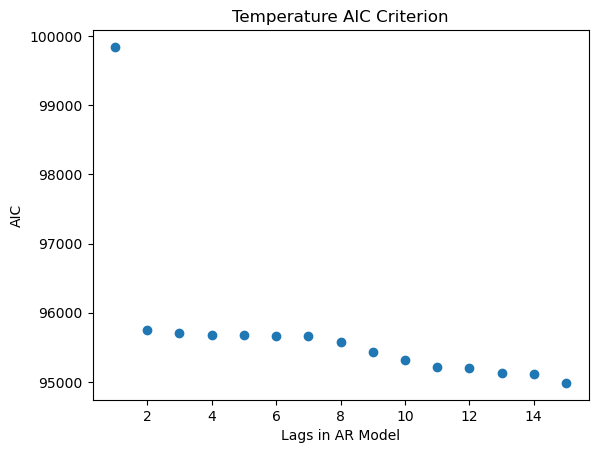

In [15]:
import matplotlib.pyplot as plt
from statsmodels.tsa.ar_model import ar_select_order

residuals = temp_resid.copy(deep=True)
mod = ar_select_order(residuals, maxlag=15, ic='aic', old_names=True)

aic = []
for key, val in mod.aic.items():
    if key != 0:
        aic.append((key[-1], val))

aic.sort()
x,y = [x for x,y in aic],[y for x,y in aic]

plt.scatter(x, y)
plt.title("Temperature AIC Criterion")
plt.xlabel("Lags in AR Model")
plt.ylabel("AIC")
plt.show()

c:\Users\gabri\miniforge3\envs\carma\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\gabri\miniforge3\envs\carma\Lib\site-packages\statsmodels\tsa\ar_model.py:2108: FutureWarning: old_names will be removed after the 0.14 release. You should stop setting this parameter and use the new names.
  full_mod = AutoReg(
c:\Users\gabri\miniforge3\envs\carma\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\gabri\miniforge3\envs\carma\Lib\site-packages\statsmodels\tsa\ar_model.py:2185: FutureWarning: old_names will be removed after the 0.14 release. You should stop setting this parameter and use the new names.
  mod = AutoReg(


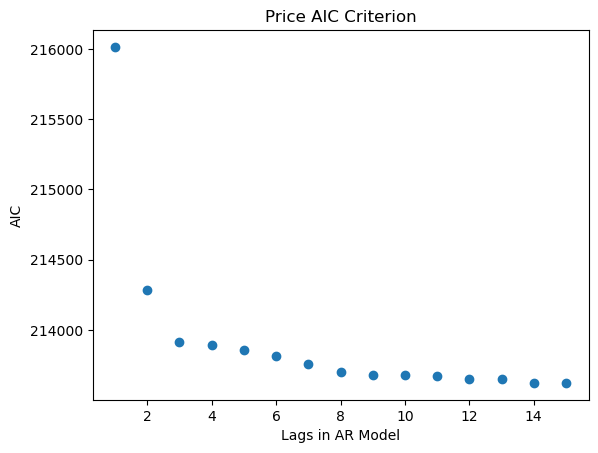

In [16]:
import matplotlib.pyplot as plt
from statsmodels.tsa.ar_model import ar_select_order

residuals = price_resid.copy(deep=True)
mod = ar_select_order(residuals, maxlag=15, ic='aic', old_names=True)

aic = []
for key, val in mod.aic.items():
    if key != 0:
        aic.append((key[-1], val))

aic.sort()
x,y = [x for x,y in aic],[y for x,y in aic]

plt.scatter(x, y)
plt.title("Price AIC Criterion")
plt.xlabel("Lags in AR Model")
plt.ylabel("AIC")
plt.show()

c:\Users\gabri\miniforge3\envs\carma\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\gabri\miniforge3\envs\carma\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\gabri\miniforge3\envs\carma\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\gabri\miniforge3\envs\carma\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\gabri\miniforge3\envs\carma\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information

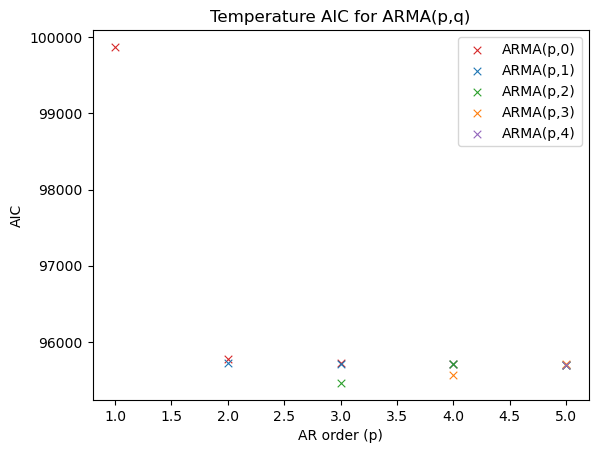

In [8]:
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import numpy as np

residuals = temp_resid.copy(deep=True)

p_values0=range(1,6)
p_values1=range(2,6)
p_values2 = range(3, 6)
p_values3=range(4,6)
p_values4=range(5,6)

aic_values_temp0=[]
#(1,0)(2,0)(3,0)(4,0)(5,0)
aic_values_temp1=[]
#(2,1)(3,1)(4,1)(5,1)
aic_values_temp2=[]
#(3,2)(4,2)(5,2)
aic_values_temp3=[]
#+(4,3)(5,3)
aic_values_temp4=[]
#(5,4)

for p in p_values0:
    model = ARIMA(residuals, order=(p,0,0))
    result = model.fit()
    aic_values_temp0.append(result.aic)

for p in p_values1:
    model = ARIMA(residuals, order=(p,0,1))
    result = model.fit()
    aic_values_temp1.append(result.aic)

for p in p_values2:
    model = ARIMA(residuals, order=(p,0,2))
    result = model.fit()
    aic_values_temp2.append(result.aic)

for p in p_values3:
    model = ARIMA(residuals, order=(p,0,3))
    result = model.fit()
    aic_values_temp3.append(result.aic)

for p in p_values4:
    model = ARIMA(residuals, order=(p,0,4))
    result = model.fit()
    aic_values_temp4.append(result.aic)

plt.scatter(p_values0, aic_values_temp0, marker='x', s=30, linewidths=0.8, color='tab:red', label='ARMA(p,0)')
plt.scatter(p_values1, aic_values_temp1, marker='x', s=30, linewidths=0.8, color='tab:blue', label='ARMA(p,1)')
plt.scatter(p_values2, aic_values_temp2, marker='x', s=30, linewidths=0.8, color='tab:green', label='ARMA(p,2)')
plt.scatter(p_values3, aic_values_temp3, marker='x', s=30, linewidths=0.8, color='tab:orange', label='ARMA(p,3)')
plt.scatter(p_values4, aic_values_temp4, marker='x', s=30, linewidths=0.8, color='tab:purple', label='ARMA(p,4)')

plt.legend()
plt.title("Temperature AIC for ARMA(p,q)")
plt.xlabel("AR order (p)")
plt.ylabel("AIC")

plt.show()

c:\Users\gabri\miniforge3\envs\carma\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\gabri\miniforge3\envs\carma\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\gabri\miniforge3\envs\carma\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\gabri\miniforge3\envs\carma\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\gabri\miniforge3\envs\carma\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information

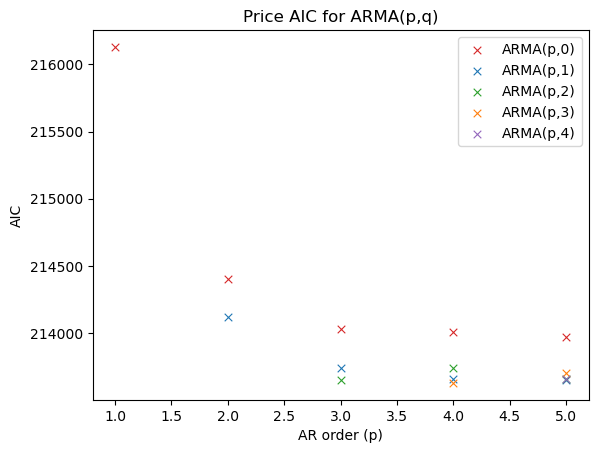

In [9]:
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import numpy as np

residuals = price_resid.copy(deep=True)

p_values0=range(1,6)
p_values1=range(2,6)
p_values2 = range(3, 6)
p_values3=range(4,6)
p_values4=range(5,6)

aic_values_price0=[]
#(1,0)(2,0)(3,0)(4,0)(5,0)
aic_values_price1=[]
#(2,1)(3,1)(4,1)(5,1)
aic_values_price2=[]
#(3,2)(4,2)(5,2)
aic_values_price3=[]
#+(4,3)(5,3)
aic_values_price4=[]
#(5,4)

for p in p_values0:
    model = ARIMA(residuals, order=(p,0,0))
    result = model.fit()
    aic_values_price0.append(result.aic)

for p in p_values1:
    model = ARIMA(residuals, order=(p,0,1))
    result = model.fit()
    aic_values_price1.append(result.aic)

for p in p_values2:
    model = ARIMA(residuals, order=(p,0,2))
    result = model.fit()
    aic_values_price2.append(result.aic)

for p in p_values3:
    model = ARIMA(residuals, order=(p,0,3))
    result = model.fit()
    aic_values_price3.append(result.aic)

for p in p_values4:
    model = ARIMA(residuals, order=(p,0,4))
    result = model.fit()
    aic_values_price4.append(result.aic)

plt.scatter(p_values0, aic_values_price0, marker='x', s=30, linewidths=0.8, color='tab:red', label='ARMA(p,0)')
plt.scatter(p_values1, aic_values_price1, marker='x', s=30, linewidths=0.8, color='tab:blue', label='ARMA(p,1)')
plt.scatter(p_values2, aic_values_price2, marker='x', s=30, linewidths=0.8, color='tab:green', label='ARMA(p,2)')
plt.scatter(p_values3, aic_values_price3, marker='x', s=30, linewidths=0.8, color='tab:orange', label='ARMA(p,3)')
plt.scatter(p_values4, aic_values_price4, marker='x', s=30, linewidths=0.8, color='tab:purple', label='ARMA(p,4)')

plt.legend()
plt.title("Price AIC for ARMA(p,q)")
plt.xlabel("AR order (p)")
plt.ylabel("AIC")

plt.show()

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import numpy as np

temp_residuals = temp_res.copy()
temp_model = ARIMA(temp_residuals, order=(2,0,1))
temp_result = temp_model.fit()


c:\Users\gabri\miniforge3\envs\carma\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\gabri\miniforge3\envs\carma\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\gabri\miniforge3\envs\carma\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


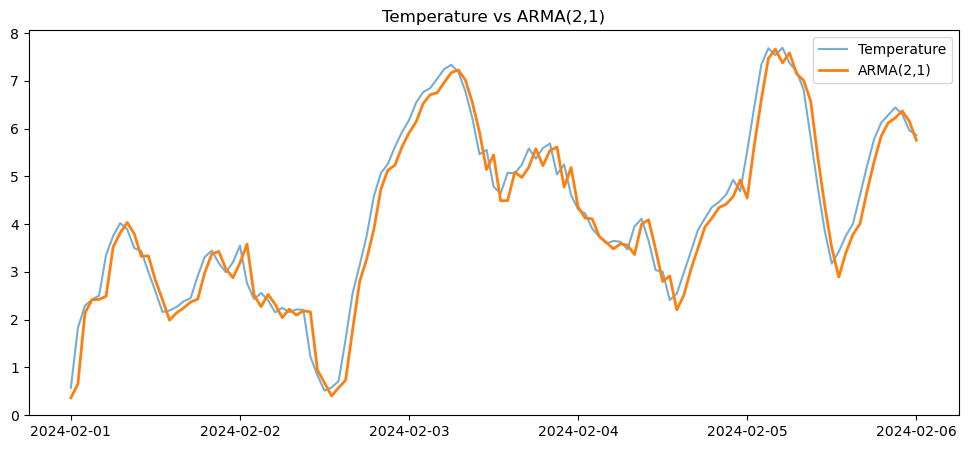

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

x_temp = pd.to_datetime(time_temp, errors="coerce").to_numpy(dtype="datetime64[ns]")
y_fit_temp = np.asarray(temp_result.fittedvalues, dtype=float)
y_res_temp = np.asarray(temp_res, dtype=float)

start_zoom = np.datetime64("2024-02-01")
end_zoom = np.datetime64("2024-02-06")

mask = (x_temp >= start_zoom) & (x_temp <= end_zoom)

plt.figure(figsize=(12, 5))
plt.plot(x_temp[mask], y_res_temp[mask], label="Temperature", alpha=0.6)
plt.plot(x_temp[mask], y_fit_temp[mask], label="ARMA(2,1)", linewidth=2)

plt.legend()
plt.title("Temperature vs ARMA(2,1)")
plt.show()

In [14]:
temp_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:        temp_deseasoned   No. Observations:                52608
Model:                 ARIMA(2, 0, 1)   Log Likelihood              -47855.557
Date:                Mon, 23 Mar 2026   AIC                          95721.115
Time:                        14:11:03   BIC                          95765.468
Sample:                    01-01-2020   HQIC                         95734.976
                         - 12-31-2025                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0005      0.149      0.004      0.997      -0.292       0.293
ar.L1          1.3758      0.012    118.004      0.000       1.353       1.399
ar.L2         -0.3921      0.012    -34.068      0.000      -0.415      -0.370
ma.L1         -0.1304      0.012    -11.142      0.000      -0.153      -0.107
sigma2         0.3611      0.001    334.666      0.000       0.359       0.363
===================================================================================
Ljung-Box (L1) (Q):                   0.05   Jarque-Bera (JB):            173409.45
Prob(Q):                              0.82   Prob(JB):                         0.00
Heteroskedasticity (H):               0.83   Skew:                            -0.91
Prob(H) (two-sided):                  0.00   Kurtosis:                        11.71
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import numpy as np

price_residuals = price_res.copy()
price_model = ARIMA(price_residuals, order=(3,0,1))
price_result = price_model.fit()

c:\Users\gabri\miniforge3\envs\carma\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\gabri\miniforge3\envs\carma\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\gabri\miniforge3\envs\carma\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


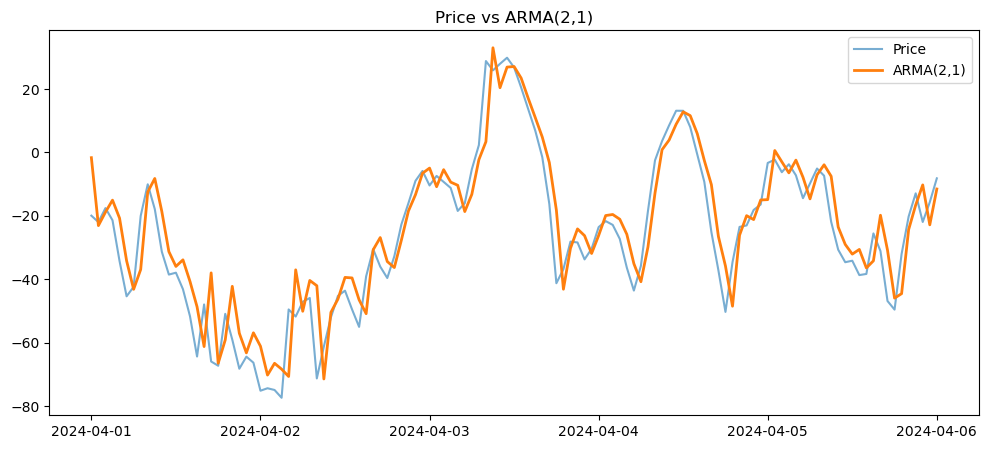

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

x_price = pd.to_datetime(time_price, errors="coerce").to_numpy(dtype="datetime64[ns]")
y_fit_price = np.asarray(price_result.fittedvalues, dtype=float)
y_res_price = np.asarray(price_res, dtype=float)

start_zoom = np.datetime64("2024-04-01")
end_zoom = np.datetime64("2024-04-06")

mask = (x_price >= start_zoom) & (x_price <= end_zoom)

plt.figure(figsize=(12, 5))
plt.plot(x_price[mask], y_res_price[mask], label="Price", alpha=0.6)
plt.plot(x_price[mask], y_fit_price[mask], label="ARMA(2,1)", linewidth=2)

plt.legend()
plt.title("Price vs ARMA(2,1)")
plt.show()

In [20]:
price_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:       price_deseasoned   No. Observations:                26281
Model:                 ARIMA(3, 0, 1)   Log Likelihood             -106862.969
Date:                Mon, 23 Mar 2026   AIC                         213737.939
Time:                        14:17:32   BIC                         213786.998
Sample:                    01-01-2023   HQIC                        213753.780
                         - 12-31-2025                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0239      1.887      0.013      0.990      -3.675       3.723
ar.L1          2.0464      0.005    410.101      0.000       2.037       2.056
ar.L2         -1.3459      0.006   -228.454      0.000      -1.357      -1.334
ar.L3          0.2943      0.002    148.857      0.000       0.290       0.298
ma.L1         -0.8973      0.005   -175.990      0.000      -0.907      -0.887
sigma2       199.2055      0.379    525.968      0.000     198.463     199.948
===================================================================================
Ljung-Box (L1) (Q):                   6.02   Jarque-Bera (JB):           4269292.44
Prob(Q):                              0.01   Prob(JB):                         0.00
Heteroskedasticity (H):               1.95   Skew:                             1.44
Prob(H) (two-sided):                  0.00   Kurtosis:                        65.37
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""